In [90]:
import torch.nn as nn
import torch

In [91]:
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from tqdm.notebook import tqdm


### Dataset Preparation (MNIST Handwritten)

In [92]:
# Define transformations for MNIST Handwritten
transform_mnist = transforms.Compose([
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST Handwritten training and test datasets
trainset_mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
testset_mnist = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

# Create data loaders
batch_size = 512
trainloader_mnist = torch.utils.data.DataLoader(trainset_mnist, batch_size=batch_size, shuffle=True)
testloader_mnist = torch.utils.data.DataLoader(testset_mnist, batch_size=batch_size, shuffle=False)

print(f"MNIST Handwritten training samples: {len(trainset_mnist)}")
print(f"MNIST Handwritten test samples: {len(testset_mnist)}")

MNIST Handwritten training samples: 60000
MNIST Handwritten test samples: 10000


### Install MedMNIST

In [93]:
!pip install medmnist


### Dataset Preparation (PneumoniaMNIST)

In [94]:
import medmnist
from medmnist import INFO, Evaluator

# Define transformations for PneumoniaMNIST
# Note: MedMNIST datasets are typically 28x28, so resize to 32x32 for LeNet
transform_pneumonia = transforms.Compose([
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]) # Common normalization for image data
])

# Load PneumoniaMNIST training and test datasets
data_flag = 'pneumoniamnist'
info = INFO[data_flag]

# MedMNIST datasets are typically 1 channel (grayscale) and have num_classes for output_size
# We also need to reshape the labels from (N, 1) to (N,) for CrossEntropyLoss

trainset_pneumonia = medmnist.PneumoniaMNIST(split='train', transform=transform_pneumonia, download=True)
trainset_pneumonia.labels = trainset_pneumonia.labels.squeeze()
testset_pneumonia = medmnist.PneumoniaMNIST(split='test', transform=transform_pneumonia, download=True)
testset_pneumonia.labels = testset_pneumonia.labels.squeeze()

# Create data loaders
trainloader_pneumonia = torch.utils.data.DataLoader(trainset_pneumonia, batch_size=batch_size, shuffle=True)
testloader_pneumonia = torch.utils.data.DataLoader(testset_pneumonia, batch_size=batch_size, shuffle=False)

print(f"PneumoniaMNIST training samples: {len(trainset_pneumonia)}")
print(f"PneumoniaMNIST test samples: {len(testset_pneumonia)}")

PneumoniaMNIST training samples: 4708
PneumoniaMNIST test samples: 624


### Dataset Preparation (MNIST Fashion)

In [95]:
# Define transformations for MNIST Fashion (same as Handwritten for input size consistency)
transform_fashion = transforms.Compose([
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Common normalization for Fashion MNIST
])

# Load MNIST Fashion training and test datasets
trainset_fashion = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_fashion)
testset_fashion = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_fashion)

# Create data loaders
trainloader_fashion = torch.utils.data.DataLoader(trainset_fashion, batch_size=batch_size, shuffle=True)
testloader_fashion = torch.utils.data.DataLoader(testset_fashion, batch_size=batch_size, shuffle=False)

print(f"MNIST Fashion training samples: {len(trainset_fashion)}")
print(f"MNIST Fashion test samples: {len(testset_fashion)}")

MNIST Fashion training samples: 60000
MNIST Fashion test samples: 10000


### Training and Evaluation Functions

In [96]:
def train_model(model, trainloader, criterion, optimizer, num_epochs=10, device='cpu', scheduler=None):
    model.train()
    model.to(device)
    history = {'loss': [], 'acc': []}

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100. * correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)

        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%, LR: {current_lr}')

        if scheduler is not None:
            scheduler.step()

    return history

In [97]:

def evaluate_model(model, testloader, device='cpu'):
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for data in tqdm(testloader, desc="[Evaluating]", leave=False):
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f'Accuracy on the test set: {accuracy:.2f}%')
    return accuracy

In [98]:
class Lenet(nn.Module):
  def __init__(self, input_size, output_size): # the input size should be 32 with padding
    super(Lenet, self).__init__()

    self.c1 = nn.Conv2d(1, 6, kernel_size=5, stride=1)
    self.s2 = nn.AvgPool2d(2, 2)

    self.c3_indices = [
        [0, 1, 2], [1, 2, 3], [2, 3, 4], [3, 4, 5], [4, 5, 0], [5, 0, 1],
        [0, 1, 2, 3], [1, 2, 3, 4], [2, 3, 4, 5], [3, 4, 5, 0], [4, 5, 0, 1], [5, 0, 1, 2],
        [0, 1, 3, 4], [1, 2, 4, 5], [0, 2, 3, 5], [0, 1, 2, 3, 4, 5]
    ]

    self.c3_lists = nn.ModuleList(
        [nn.Conv2d(len(idx), 1, kernel_size=5, stride=1) for idx in self.c3_indices]
    )

    self.s4 = nn.AvgPool2d(2, 2)
    self.c5 = nn.Conv2d(16, 120, stride=1, kernel_size=5)
    self.fc6 = nn.Linear(120, 84)
    self.output = nn.Linear(84, output_size)

  def forward(self, x):

    # Inserts a dimension with a size of one (a singleton dimension) into the tensor's shape.
    if x.dim() == 3:
      x = x.unsqueeze(0)

    x = torch.tanh(self.c1(x))
    x = torch.tanh(self.s2(x))

    outputs = []
    for i, idx in enumerate(self.c3_indices):
      outputs.append(self.c3_lists[i](x[:, idx, :, :]))

    x = torch.tanh(torch.cat(outputs, dim=1))
    x = torch.tanh(self.s4(x))
    x = torch.tanh(self.c5(x))

    # x is now of shape (N, 120, 1, 1) and need to be at shape (N, 120) to proceed so we use x.view

    x = x.view(x.shape[0], -1)

    x = torch.tanh(self.fc6(x))

    return self.output(x)


In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

def plot_history(history, title="Training History"):
    """Vẽ biểu đồ Loss và Accuracy từ lịch sử huấn luyện"""
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='tab:red')
    ax1.plot(history['loss'], color='tab:red', label='Loss')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Accuracy (%)', color='tab:blue')
    ax2.plot(history['acc'], color='tab:blue', label='Accuracy')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title(title)
    fig.tight_layout()
    plt.show()

def plot_confusion_matrix(model, testloader, device, classes, title="Confusion Matrix"):
    """Dự đoán và vẽ ma trận nhầm lẫn"""
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

### LeNet on MNIST Handwritten


--- Training LeNet on MNIST Handwritten ---


Epoch 1/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 1, Loss: 0.2674, Acc: 91.90%, LR: 0.01


Epoch 2/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 2, Loss: 0.0791, Acc: 97.59%, LR: 0.01


...

Epoch 28, Loss: 0.0020, Acc: 99.97%, LR: 0.0001


Epoch 29/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 29, Loss: 0.0020, Acc: 99.97%, LR: 0.0001


Epoch 30/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 30, Loss: 0.0020, Acc: 99.97%, LR: 0.0001


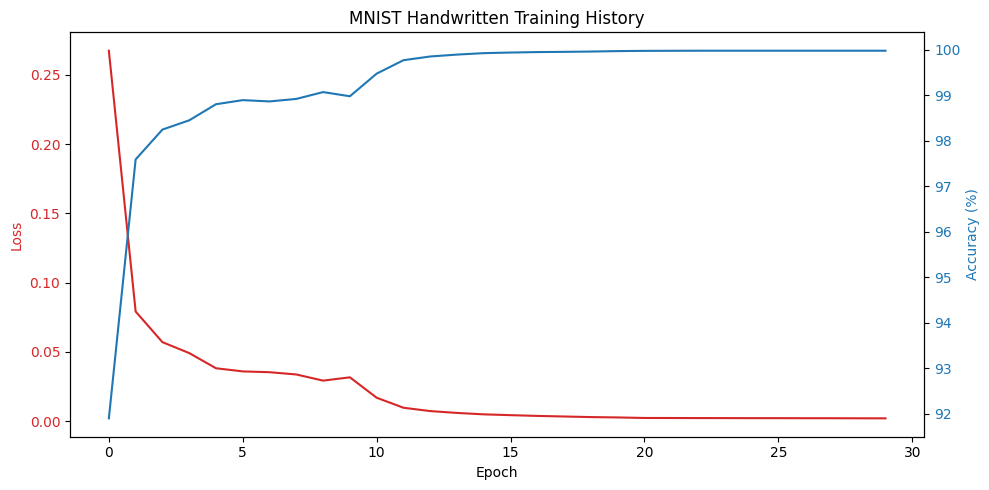

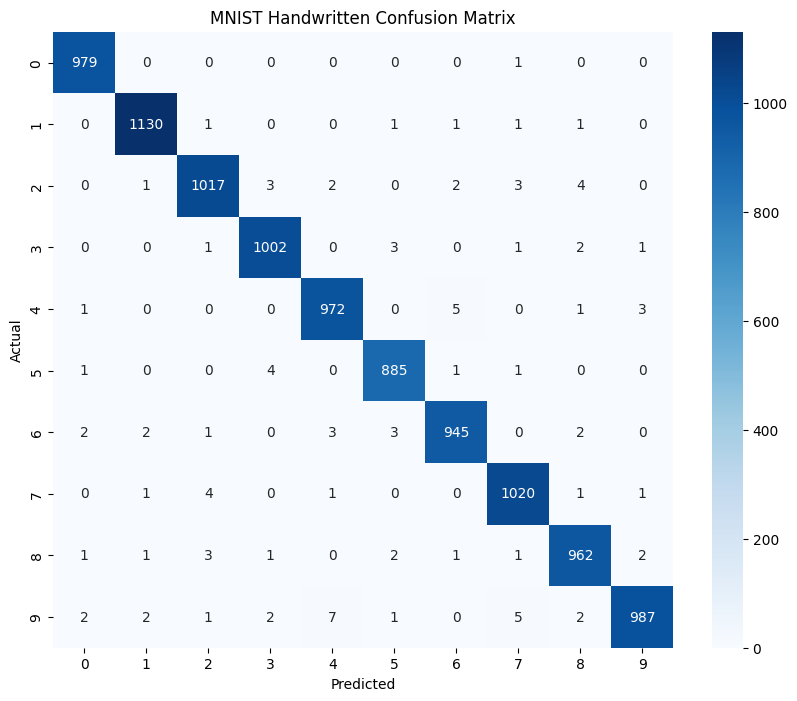

In [100]:
print("\n--- Training LeNet on MNIST Handwritten ---")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
lenet_mnist = Lenet(input_size=32, output_size=10)
criterion_mnist = nn.CrossEntropyLoss()
optimizer_mnist = optim.Adam(lenet_mnist.parameters(), lr=0.01)
# Khởi tạo scheduler
scheduler_mnist = optim.lr_scheduler.StepLR(optimizer_mnist, step_size=10, gamma=0.1)

# Huấn luyện với scheduler
history_mnist = train_model(lenet_mnist, trainloader_mnist, criterion_mnist, optimizer_mnist, num_epochs=30, device=device, scheduler=scheduler_mnist)
plot_history(history_mnist, title="MNIST Handwritten Training History")

classes_mnist = [str(i) for i in range(10)]
plot_confusion_matrix(lenet_mnist, testloader_mnist, device, classes_mnist, title="MNIST Handwritten Confusion Matrix")

In [101]:
_ = evaluate_model(lenet_mnist, testloader_mnist, device=device)


[Evaluating]:   0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the test set: 98.99%


### LeNet on MNIST Fashion


--- Training LeNet on MNIST Fashion ---


Epoch 1/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 1, Loss: 0.5973, Acc: 77.82%, LR: 0.01


Epoch 2/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 2, Loss: 0.3840, Acc: 85.84%, LR: 0.01


...

Epoch 28, Loss: 0.1305, Acc: 95.52%, LR: 0.0001


Epoch 29/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 29, Loss: 0.1300, Acc: 95.56%, LR: 0.0001


Epoch 30/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 30, Loss: 0.1298, Acc: 95.56%, LR: 0.0001


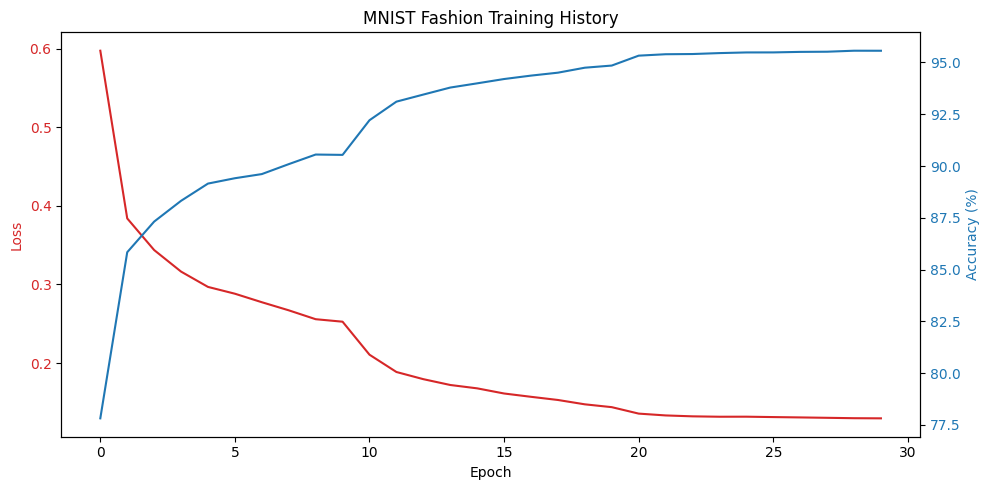

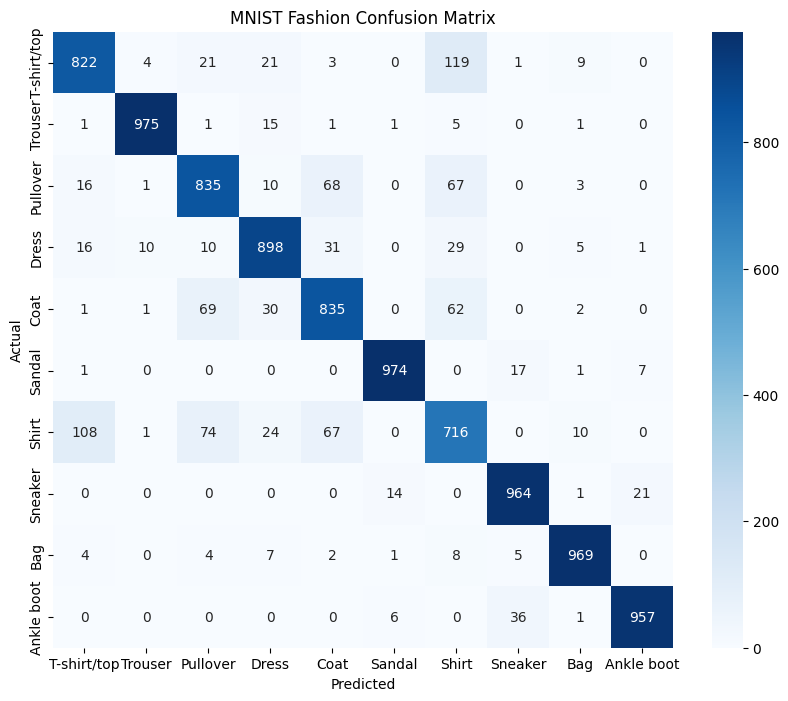

[Evaluating]:   0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the test set: 89.45%


In [102]:
print("\n--- Training LeNet on MNIST Fashion ---")
lenet_fashion = Lenet(input_size=32, output_size=10)
criterion_fashion = nn.CrossEntropyLoss()
optimizer_fashion = optim.Adam(lenet_fashion.parameters(), lr=0.01)
scheduler_fashion = optim.lr_scheduler.StepLR(optimizer_fashion, step_size=10, gamma=0.1)

history_fashion = train_model(lenet_fashion, trainloader_fashion, criterion_fashion, optimizer_fashion, num_epochs=30, device=device, scheduler=scheduler_fashion)
plot_history(history_fashion, title="MNIST Fashion Training History")

classes_fashion = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plot_confusion_matrix(lenet_fashion, testloader_fashion, device, classes_fashion, title="MNIST Fashion Confusion Matrix")
_ = evaluate_model(lenet_fashion, testloader_fashion, device=device)

### LeNet on PneumoniaMNIST


--- Training LeNet on PneumoniaMNIST ---


Epoch 1/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1, Loss: 0.5448, Acc: 71.47%, LR: 0.01


Epoch 2/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 2, Loss: 0.2484, Acc: 88.98%, LR: 0.01


...

Epoch 28, Loss: 0.0900, Acc: 96.50%, LR: 0.0001


Epoch 29/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 29, Loss: 0.0875, Acc: 96.50%, LR: 0.0001


Epoch 30/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 30, Loss: 0.0897, Acc: 96.50%, LR: 0.0001


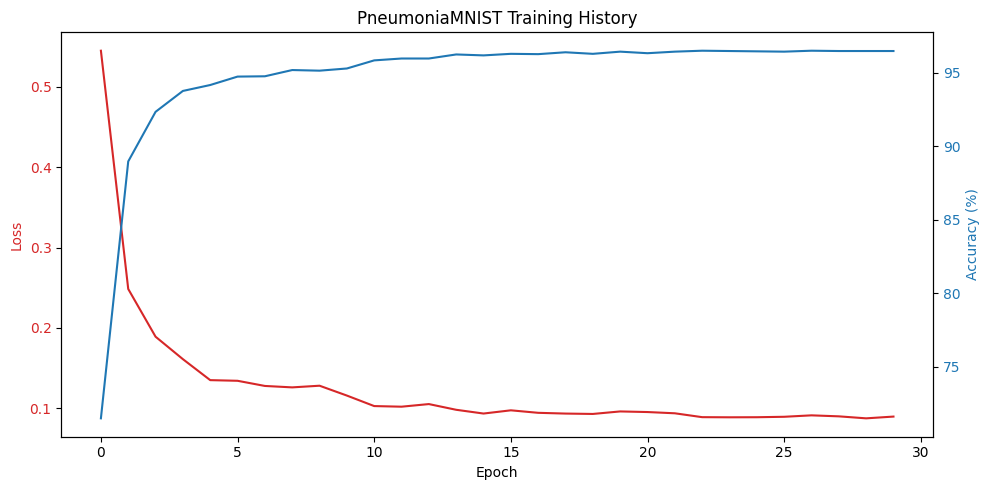

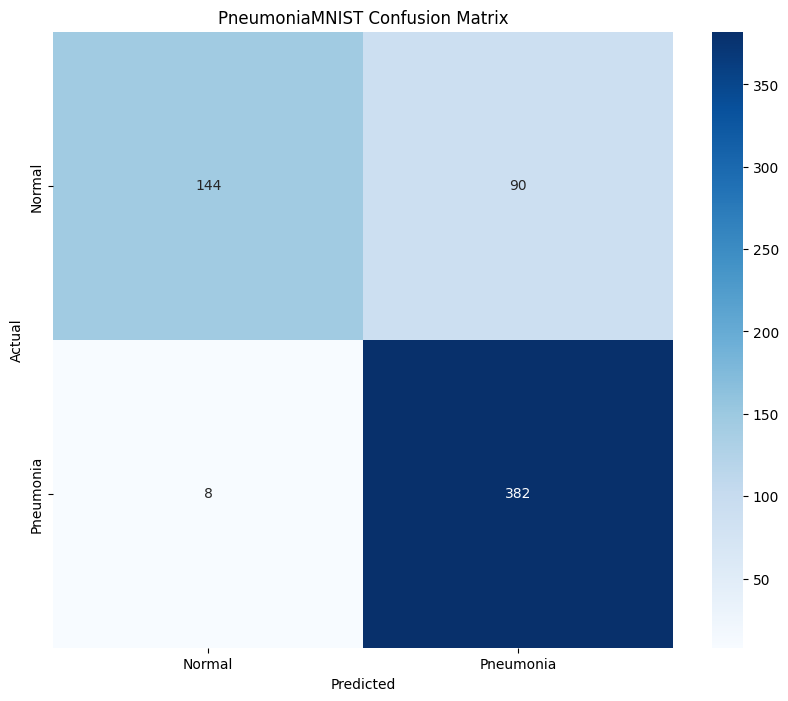

[Evaluating]:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 84.29%


In [103]:
print("\n--- Training LeNet on PneumoniaMNIST ---")
lenet_pneumonia = Lenet(input_size=32, output_size=2)
criterion_pneumonia = nn.CrossEntropyLoss()
optimizer_pneumonia = optim.Adam(lenet_pneumonia.parameters(), lr=0.01)
scheduler_pneumonia = optim.lr_scheduler.StepLR(optimizer_pneumonia, step_size=10, gamma=0.1)

history_pneumonia = train_model(lenet_pneumonia, trainloader_pneumonia, criterion_pneumonia, optimizer_pneumonia, num_epochs=30, device=device, scheduler=scheduler_pneumonia)
plot_history(history_pneumonia, title="PneumoniaMNIST Training History")

classes_pneumonia = ['Normal', 'Pneumonia']
plot_confusion_matrix(lenet_pneumonia, testloader_pneumonia, device, classes_pneumonia, title="PneumoniaMNIST Confusion Matrix")
_ = evaluate_model(lenet_pneumonia, testloader_pneumonia, device=device)
